# Multi-Model Switching

## Overview

In this tutorial we look at **runtime model switching**: exchanging one component of a running
co-simulation for an alternative model of the same subsystem, while every other component stays
coupled and keeps advancing.

A `MultiComponent` wraps several interchangeable models under one port interface and keeps exactly
one of them active. The question this tutorial is about is not *whether* it switches, but **when**:

- with a `mode_selector`, the decision is polled at the top of each macro step, so the switch lands
  on the communication grid;
- with a **switch indicator**, the decision becomes a zero-crossing condition, so the hybrid
  algorithm localizes it by bisection and the switch lands on the crossing itself.

The difference is a placement error of up to one macro step, and it does not stay inside the
switching component: the coupled partners integrate against whichever model is active, so a
misplaced switch feeds the wrong dynamics into their inputs.

## Learning Goals

- Understand the difference between grid-based and event-localized mode switching.
- Register a switching condition with `add_switch_indicator()`.
- Measure the switch placement error of both strategies and see how it scales with the step size.
- Understand how hysteresis guards a localized switch against chattering.

## Prerequisites and Setup

This tutorial builds on the earlier advanced tutorials, in particular the hybrid event handling
introduced in *Hybrid Event Chain* and *Internal Event Reporting*. Familiarity with event
indicators, zero-crossing detection, and bisection-based event localization is assumed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from syssimx.core.base import CoSimComponent
from syssimx.core.multi_comp import Hysteresis, ModeKey, MultiComponent
from syssimx.core.port import PortSpec, PortType
from syssimx.system.algorithms.hybrid import HybridAlgorithm
from syssimx.system.system import System

## A Minimal Switchable Plant

To make the switch instant measurable, we use a model whose crossing time is known in closed form.
`RampModel` integrates its output at a constant rate, so with $y(0) = 0$ we simply have

$$y(t) = r \, t$$

and the threshold $y = y_\mathrm{sw}$ is reached at exactly $t_\mathrm{sw} = y_\mathrm{sw} / r$.

Two instances with different rates give us two distinguishable modes. Note that the model
implements `snapshot_state()` and `restore_state()`: rollback is what allows the hybrid algorithm
to bisect, and therefore a precondition for any event indicator.

In [2]:
class RampModel(CoSimComponent):
    """Integrates y at a constant rate. Supports rollback, so events can be localized."""

    def __init__(self, name: str, rate: float):
        super().__init__(name, label=name)
        self.rate = rate
        self._y = 0.0
        self.output_specs = {
            "y": PortSpec(name="y", type=PortType.REAL, unit="m", direction="out"),
        }

    def _initialize_component(self, t0: float) -> None:
        self._y = 0.0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self._y += self.rate * dt

    def _update_output_states(self, t=None, event_names=None) -> None:
        self.outputs["y"].set(self._y, t=t)
        self._apply_event_ports(t, event_names)

    def get_state(self):
        return {"y": self._y}

    def set_state(self, state, t: float) -> None:
        self._y = float(state["y"])

    def snapshot_state(self):
        return {"y": self._y}

    def restore_state(self, snapshot, t: float) -> None:
        self._y = float(snapshot["y"])

    def reset(self) -> None:
        self._y = 0.0

The `MultiComponent` subclass registers both models and defines how state is carried across a
switch. Here both modes share the same state format, so `_adapt_state` passes it through
unchanged. In a heterogeneous setup this is where a FEM displacement field would be reduced to a
rigid-body angle, or vice versa.

In [3]:
class SwitchingPlant(MultiComponent):
    """Two ramp models under one interface: SLOW (rate 1) and FAST (rate 4)."""

    def __init__(self, name: str = "Plant", initial_mode: ModeKey = "SLOW"):
        models = {
            "SLOW": RampModel(f"{name}_SLOW", rate=1.0),
            "FAST": RampModel(f"{name}_FAST", rate=4.0),
        }
        super().__init__(name, models=models, initial_mode=initial_mode)
        self._unify_ports()

    def _adapt_state(self, state, target_mode):
        # Both modes store the same physical quantity, so no translation is needed.
        return state.copy()

Port values carry Pint units, so a switching condition has to unwrap the magnitude before
comparing it against a plain float.

In [4]:
def magnitude(value, default: float = 0.0) -> float:
    """Unwrap a port value, which may be a Pint Quantity."""
    if value is None:
        return default
    return float(getattr(value, "magnitude", value))


THRESHOLD = 0.93   # switch when y reaches this value
T_CROSS = 0.93     # SLOW has rate 1.0, so y(t) = t and the crossing is at t = 0.93 s
T_END = 2.0

## Strategy 1: Grid-Based Switching

A `mode_selector` is a function of time that returns the mode that should be active. The wrapper
calls it at the start of every macro step, so the earliest it can react is the first grid point at
or after the condition becomes true.

In [5]:
def run(plant: SwitchingPlant, dt: float, t_end: float = T_END) -> System:
    """Build a one-component system around the plant and simulate it."""
    system = System(name="SwitchingSystem")
    system.add_component(plant)
    system.algorithm = HybridAlgorithm()
    system.algorithm.verbose = False
    system.initialize(t0=0.0)
    system.run(t0=0.0, tf=t_end, dt=dt)
    return system


def switch_times(plant: SwitchingPlant) -> list[float]:
    """Times at which the wrapper actually changed mode."""
    return [float(event["time"]) for event in plant.sync_events]

In [6]:
def build_grid_plant() -> SwitchingPlant:
    plant = SwitchingPlant()
    plant.mode_selector = lambda t: (
        "FAST" if magnitude(plant.outputs["y"].get()) >= THRESHOLD else "SLOW"
    )
    return plant


grid_plant = build_grid_plant()
grid_system = run(grid_plant, dt=0.2)

print(f"analytic crossing : t = {T_CROSS:.4f} s")
print(f"switch applied at : t = {switch_times(grid_plant)[0]:.4f} s")

analytic crossing : t = 0.9300 s
switch applied at : t = 1.0000 s


The switch is late. With a macro step of 0.2 s the condition becomes true during the step that ends
at $t = 1.0$ s, and that is the first moment the selector is consulted.

## Strategy 2: Event-Localized Switching

`add_switch_indicator()` registers the same condition as a zero-crossing function instead. The
wrapper then exposes it as an ordinary event, the hybrid algorithm detects the crossing, narrows it
by bisection, and applies the switch at the located instant.

The indicator is evaluated against the **wrapper**, not against the active sub-model, so it reads
the unified output ports and keeps working no matter which mode is active.

In [7]:
def build_localized_plant() -> SwitchingPlant:
    plant = SwitchingPlant()
    plant.add_switch_indicator(
        name="to_fast",
        func=lambda c: magnitude(c.outputs["y"].get()) - THRESHOLD,
        target_mode="FAST",
        direction=1,   # rising crossing only
    )
    return plant


localized_plant = build_localized_plant()
localized_system = run(localized_plant, dt=0.2)

print(f"analytic crossing : t = {T_CROSS:.4f} s")
print(f"switch applied at : t = {switch_times(localized_plant)[0]:.4f} s")

analytic crossing : t = 0.9300 s
switch applied at : t = 0.9300 s


The switch now sits on the crossing itself, to the tolerance of the bisection, even though the
communication grid never contains that instant.

## Comparing the Trajectories

Plotting both runs against the exact solution shows what the placement error costs. The exact
trajectory ramps at rate 1 until $t_\mathrm{sw}$ and at rate 4 afterwards.

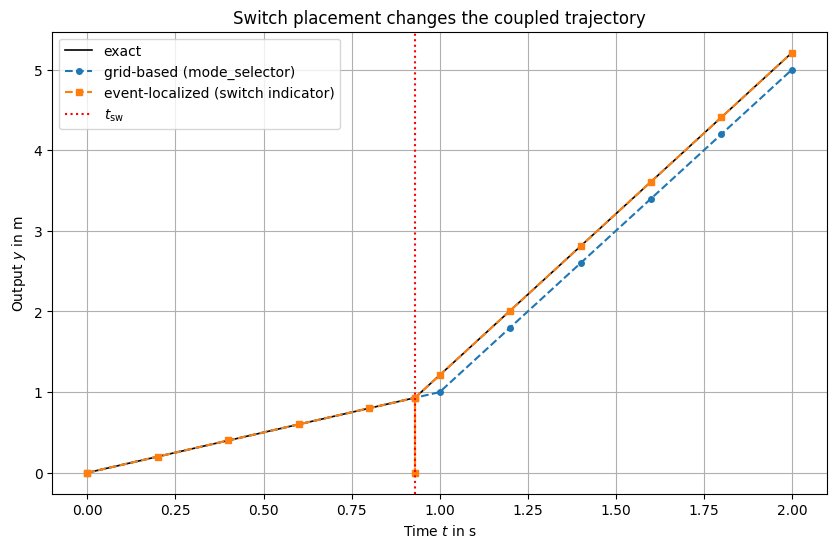

In [8]:
def exact_trajectory(t: np.ndarray) -> np.ndarray:
    """Analytic y(t): rate 1 before the crossing, rate 4 after it."""
    return np.where(t <= T_CROSS, t, THRESHOLD + 4.0 * (t - T_CROSS))


def history(system: System) -> tuple[np.ndarray, np.ndarray]:
    t_vals, data = system.get_history()["Plant"]
    return np.asarray(t_vals, dtype=float), np.asarray(data["y"], dtype=float)


t_grid, y_grid = history(grid_system)
t_loc, y_loc = history(localized_system)
t_fine = np.linspace(0.0, T_END, 400)

plt.figure(figsize=(10, 6))
plt.plot(t_fine, exact_trajectory(t_fine), "k-", lw=1.2, label="exact")
plt.plot(t_grid, y_grid, "o--", ms=4, label="grid-based (mode_selector)")
plt.plot(t_loc, y_loc, "s--", ms=4, label="event-localized (switch indicator)")
plt.axvline(T_CROSS, color="red", ls=":", label=r"$t_\mathrm{sw}$")
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Output $y$ in m")
plt.title("Switch placement changes the coupled trajectory")
plt.grid(True)
plt.legend(loc="upper left")
plt.show()

## How the Placement Error Scales

Because the grid-based switch can only land on a communication point, its error is bounded by the
macro step: it shrinks as the grid is refined, but jumps around within that bound depending on how
close a grid point happens to fall to the crossing. The localized switch is limited by the
bisection tolerance instead, which does not depend on the step size at all.

In [9]:
step_sizes = [0.4, 0.2, 0.1, 0.05, 0.025]
err_grid, err_localized = [], []

for dt in step_sizes:
    g = build_grid_plant()
    run(g, dt=dt)
    err_grid.append(abs(switch_times(g)[0] - T_CROSS))

    loc = build_localized_plant()
    run(loc, dt=dt)
    err_localized.append(abs(switch_times(loc)[0] - T_CROSS))

for dt, eg, el in zip(step_sizes, err_grid, err_localized):
    print(f"dt = {dt:6.3f} s   grid error = {eg:.3e} s   localized error = {el:.3e} s")

dt =  0.400 s   grid error = 2.700e-01 s   localized error = 3.052e-07 s
dt =  0.200 s   grid error = 7.000e-02 s   localized error = 3.052e-07 s
dt =  0.100 s   grid error = 7.000e-02 s   localized error = 3.052e-07 s
dt =  0.050 s   grid error = 2.000e-02 s   localized error = 3.052e-07 s
dt =  0.025 s   grid error = 2.000e-02 s   localized error = 3.052e-07 s


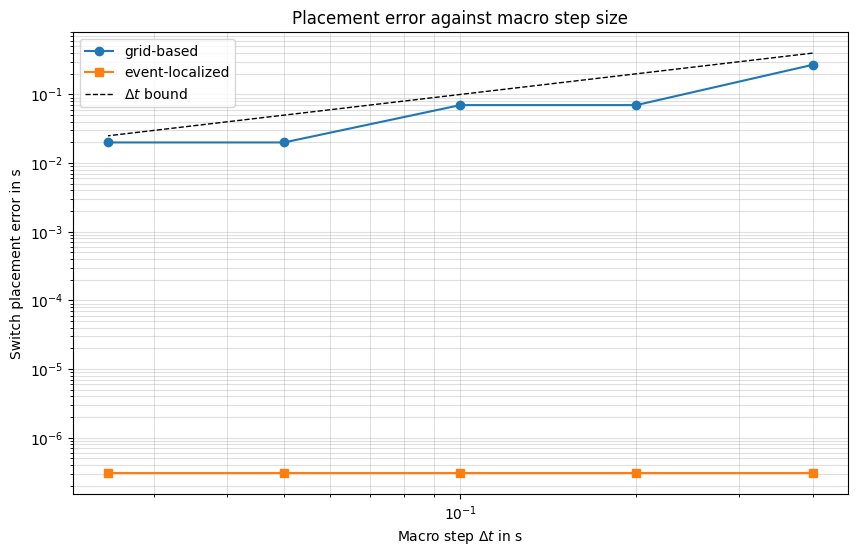

In [10]:
plt.figure(figsize=(10, 6))
plt.loglog(step_sizes, err_grid, "o-", label="grid-based")
plt.loglog(step_sizes, err_localized, "s-", label="event-localized")
plt.loglog(step_sizes, step_sizes, "k--", lw=1, label=r"$\Delta t$ bound")
plt.xlabel(r"Macro step $\Delta t$ in s")
plt.ylabel("Switch placement error in s")
plt.title("Placement error against macro step size")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.show()

The grid-based error stays under the $\Delta t$ bound and falls as the grid is refined, with a
sawtooth wherever a grid point happens to land close to the crossing. The localized error sits flat
at the bisection tolerance, a few times $10^{-7}\,\mathrm{s}$ here, regardless of the macro step.

This matters beyond the switching component itself. Any partner coupled to this plant integrates
against whichever model is active, so a switch placed up to one macro step late injects the wrong
dynamics into the partners' inputs for that interval. Localizing the switch removes that error
term from the whole coupled system, not only from the component that switched.

## What Happens Under the Hood

A switch indicator is deliberately *not* a separate mechanism. It is registered in the same
indicator registry that physical state events use, so the existing hybrid machinery carries it:

1. `evaluate_event_indicators()` returns the active sub-model's indicators **and** the wrapper's
   switch indicators, merged into one mapping.
2. The hybrid algorithm takes a rolled-back trial step and compares the values on both sides of the
   interval. During that trial step mode switching is suppressed, because a state snapshot is only
   valid for the model that produced it.
3. When a crossing is found, bisection narrows the interval to the tolerance.
4. The state is advanced to the located instant, and only then is the event handled.
5. `MultiComponent` handles the event by first passing any physical events to the outgoing model,
   and then performing the mode switch, so the state handed over is the post-event state.

Because the switch is an event, it also appears as an EVENT output port on the wrapper, and can be
observed or connected like any other event.

In [11]:
print("registered indicators :", list(localized_plant.event_indicators))
print("switch targets        :", localized_plant._switch_targets)
print("event output port     :", "to_fast" in localized_plant.output_specs)
print("switch record         :", localized_plant.sync_events)

registered indicators : ['to_fast']
switch targets        : {'to_fast': 'FAST'}
event output port     : True
switch record         : [{'time': 0.9300003051757811, 'from_mode': 'SLOW', 'to_mode': 'FAST'}]


## Guarding Against Chattering

Localizing a switch places the state exactly on the switching boundary, which is precisely where
the condition is most likely to trigger again. A `Hysteresis` guard enforces a minimum dwell time
between switches and is applied to both strategies alike: if the dwell window is still open when
the crossing fires, the switch is skipped and the condition may fire again later.

In [12]:
guarded = build_localized_plant()
guarded.hysteresis = Hysteresis(dwell_time=T_END)   # long enough to block the whole run
guarded.hysteresis.record_switch(t=0.0)             # pretend a switch just happened

run(guarded, dt=0.2)

print(f"active mode after run : {guarded.active_mode}")
print(f"switches recorded     : {switch_times(guarded)}")

active mode after run : SLOW
switches recorded     : []


## Summary

- A `MultiComponent` can decide *when* to switch in two ways, and the choice determines the
  accuracy of the transition.
- `mode_selector` is polled on the communication grid, so its placement error is $\mathcal{O}
  (\Delta t)$.
- `add_switch_indicator()` expresses the same condition as a zero-crossing, so the hybrid
  algorithm localizes it by bisection and the error drops to the bisection tolerance.
- The switch is applied while handling the localized event, after physical events have been passed
  to the outgoing model, which keeps the state handover consistent.
- Because coupled partners keep running across the switch, reducing the placement error benefits
  the whole system, not just the component that switched.
- `Hysteresis` remains available in both strategies to prevent repeated switching at the boundary.